In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.constants import YRSID_SI
import os
import sys

# Changing directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Configuration
use_gpu = True
force_backend = "cuda12x"
dt = 10.0  # seconds
T = 2.0  # years (use 2 years for full evolution)

# Waveform generator setup
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs = {
    "force_backend": force_backend,
    "pad_output": True,
}

waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)



In [8]:
# Source parameters 
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15 #11.7 if u want to plunge, original = 15
e0 = 0.4
xI0 = 1.0
dist = 0.25  # Gpc
qS = np.pi
phiS = 0
qK = 0
phiK = 0
# qS = 0.5   
# phiS = 1.0        
# qK = 1.0      
# phiK = 1.0 + np.pi/3  
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

# PAPER
# m1 = 1e6
# m2 = 10 
# a= 0.5
# p0=9.5
# e0=0.2
# xI0 = 1.0 #keep equatorial
# # below are randomly chosen
# dist = 0.25  # Gpc
# qS = 0.5
# phiS = 1.0
# qK = 1.0
# phiK = phiS + np.pi/3
# Phi_phi0 = 0.
# Phi_theta0 = 0.
# Phi_r0 = 0.

params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

In [9]:
def get_viewing_angles(qS, phiS, qK, phiK):
    """Transform from the detector frame to the source  frame"""
    cqS = np.cos(qS)
    sqS = np.sin(qS)
    cphiS = np.cos(phiS)
    sphiS = np.sin(phiS)
    cqK = np.cos(qK)
    sqK = np.sin(qK)
    cphiK = np.cos(phiK)
    sphiK = np.sin(phiK)
    # sky location vector
    R = np.array([sqS * cphiS, sqS * sphiS, cqS])
    # spin vector
    S = np.array([sqK * cphiK, sqK * sphiK, cqK])
    print(R,S)
    # get viewing angles
    phi = -np.pi / 2.0  # by definition of source frame
    theta = np.arccos(-np.dot(R, S))  # normalized vector

    return (theta, phi)

In [10]:
theta, phi = get_viewing_angles(qS, phiS, qK, phiK)
theta, phi

[ 1.2246468e-16  0.0000000e+00 -1.0000000e+00] [0. 0. 1.]


(np.float64(0.0), -1.5707963267948966)

In [11]:
theta*180/np.pi

np.float64(0.0)

In [12]:
print("Generating waveform...")
h = waveform_gen(*params, T=T, dt=dt)

Generating waveform...


In [13]:
h

array([9.09300190e-22+1.57864033e-21j, 1.02335984e-21+1.47031300e-21j,
       1.12357682e-21+1.35625703e-21j, ...,
       2.09802876e-22-1.05238361e-21j, 1.54965365e-22-1.07171918e-21j,
       9.81372606e-23-1.08857758e-21j], shape=(6311630,))

In [14]:
h_real = h.real
h_real

array([9.09300190e-22, 1.02335984e-21, 1.12357682e-21, ...,
       2.09802876e-22, 1.54965365e-22, 9.81372606e-23], shape=(6311630,))

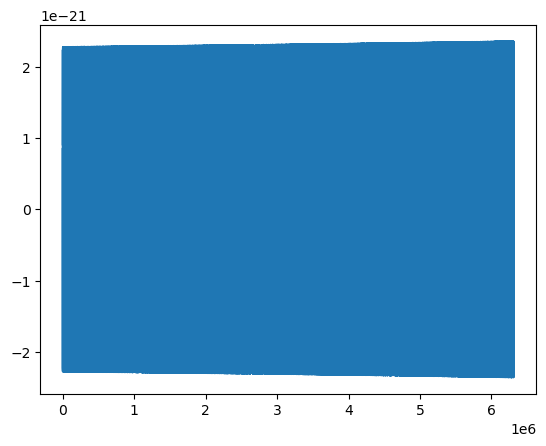

In [15]:
plt.plot(h_real.get())
plt.show()

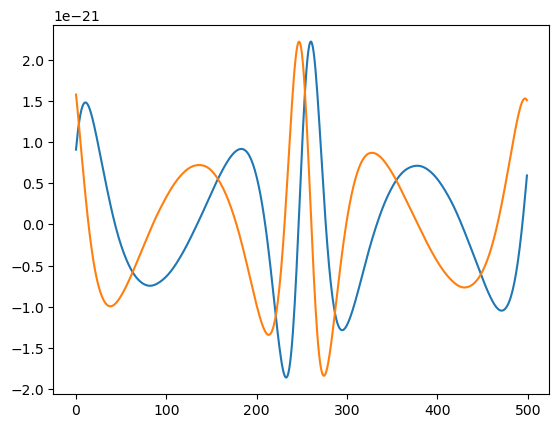

In [16]:
plt.plot(h_real.get()[:500])
plt.plot(h.imag.get()[:500])

plt.show()

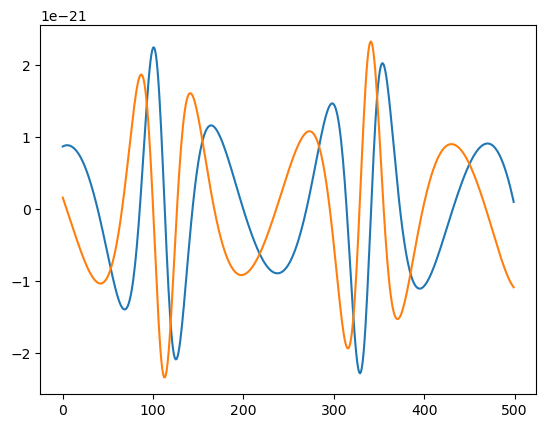

In [17]:
plt.plot(h_real.get()[6311630-500:6311630])
plt.plot(h.imag.get()[6311630-500:6311630])

plt.show()

In [18]:
print(f"Signal length: {len(h_real)} samples")
print(f"Duration: {len(h_real) * dt / YRSID_SI:.2f} years")


Signal length: 6311630 samples
Duration: 2.00 years


In [19]:
# Generate trajectory to get fundamental frequencies
print("Computing fundamental frequencies...")
from few.trajectory.inspiral import EMRIInspiral
N_traj = 5000
delta_T = T*YRSID_SI/5000
traj_gen = EMRIInspiral(func='KerrEccEqFlux')
t_arr, p_arr, e_arr, x_arr, Phi_phi_arr, Phi_theta_arr, Phi_r_arr = traj_gen(
    m1, m2, a, p0, e0, xI0, T=T, dt=dt, upsample=True,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0
)

Computing fundamental frequencies...


In [20]:
from few.utils.utility import get_p_at_t

get_p_at_t(traj_module=traj_gen, t_out=T, traj_args=[m1, m2, a, e0, xI0])


11.606899362008043

In [21]:
p_arr, e_arr

(array([15.        , 14.9999998 , 14.99999961, ..., 13.54804856,
        13.54804828, 13.54804801], shape=(6311629,)),
 array([0.4       , 0.39999999, 0.39999998, ..., 0.34303788, 0.34303787,
        0.34303786], shape=(6311629,)))

In [22]:

# Get fundamental frequencies along trajectory
freqs_list = []
for p_val, e_val in zip(p_arr, e_arr):
    Om_phi, Om_theta, Om_r = get_fundamental_frequencies(a, p_val, e_val, xI0)
    freqs_list.append([Om_phi, Om_theta, Om_r])

freqs_list

[[0.013517301972037083, 0.013228159781958215, 0.011217533869073239],
 [0.013517302372576949, 0.013228160168639662, 0.011217534173103286],
 [0.013517302773130303, 0.01322816055532916, 0.011217534477140344],
 [0.01351730317369003, 0.013228160942014774, 0.011217534781173988],
 [0.013517303574245366, 0.013228161328698819, 0.011217535085206303],
 [0.013517303974811844, 0.013228161715389307, 0.011217535389244231],
 [0.013517304375355815, 0.013228162102068829, 0.011217535693272523],
 [0.013517304775921658, 0.013228162488752401, 0.011217535997304467],
 [0.013517305176469, 0.013228162875441478, 0.011217536301341088],
 [0.013517305577032323, 0.013228163262128636, 0.01121753660537603],
 [0.013517305977584685, 0.013228163648810248, 0.011217536909406368],
 [0.01351730637814251, 0.013228164035500178, 0.01121753721344365],
 [0.013517306778688908, 0.013228164422185456, 0.011217537517477056],
 [0.013517307179264415, 0.013228164808868374, 0.011217537821508382],
 [0.013517307579818023, 0.0132281651955580

In [23]:
freqs_arr = np.array(freqs_list)
from few.utils.constants import MTSUN_SI
M = m1+m2
Msec = M * MTSUN_SI  # Total mass in seconds
freq_phi = freqs_arr[:, 0] / (2 * np.pi * Msec)  # Convert to Hz
freq_theta = freqs_arr[:, 1] / (2 * np.pi * Msec)
freq_r = freqs_arr[:, 2] / (2 * np.pi * Msec)

In [24]:
modes = [
    (l, m, n) 
    for l in range(2, 4) 
    for m in range(-l, l + 1)
    for n in range(-5, 2)
]

# Compute mode frequencies
mode_freqs = []
for l, m, n in modes:
    f_mode = m * freq_phi + n * freq_r
    mode_freqs.append(f_mode)

In [25]:
len(modes), len(mode_freqs)

(84, 84)

In [26]:
modes_l2_all = [
    (2, m, n) 
    for m in range(-2,3)
    for n in range(-55,56)
]
modes_l2_all

[(2, -2, -55),
 (2, -2, -54),
 (2, -2, -53),
 (2, -2, -52),
 (2, -2, -51),
 (2, -2, -50),
 (2, -2, -49),
 (2, -2, -48),
 (2, -2, -47),
 (2, -2, -46),
 (2, -2, -45),
 (2, -2, -44),
 (2, -2, -43),
 (2, -2, -42),
 (2, -2, -41),
 (2, -2, -40),
 (2, -2, -39),
 (2, -2, -38),
 (2, -2, -37),
 (2, -2, -36),
 (2, -2, -35),
 (2, -2, -34),
 (2, -2, -33),
 (2, -2, -32),
 (2, -2, -31),
 (2, -2, -30),
 (2, -2, -29),
 (2, -2, -28),
 (2, -2, -27),
 (2, -2, -26),
 (2, -2, -25),
 (2, -2, -24),
 (2, -2, -23),
 (2, -2, -22),
 (2, -2, -21),
 (2, -2, -20),
 (2, -2, -19),
 (2, -2, -18),
 (2, -2, -17),
 (2, -2, -16),
 (2, -2, -15),
 (2, -2, -14),
 (2, -2, -13),
 (2, -2, -12),
 (2, -2, -11),
 (2, -2, -10),
 (2, -2, -9),
 (2, -2, -8),
 (2, -2, -7),
 (2, -2, -6),
 (2, -2, -5),
 (2, -2, -4),
 (2, -2, -3),
 (2, -2, -2),
 (2, -2, -1),
 (2, -2, 0),
 (2, -2, 1),
 (2, -2, 2),
 (2, -2, 3),
 (2, -2, 4),
 (2, -2, 5),
 (2, -2, 6),
 (2, -2, 7),
 (2, -2, 8),
 (2, -2, 9),
 (2, -2, 10),
 (2, -2, 11),
 (2, -2, 12),
 (2, -2, 13)

In [27]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2_all, include_minus_mkn=False)

(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


In [28]:
import scipy
fs = 1.0 / dt  # Sampling frequency
nperseg = 2**16  # Window size for STFT
noverlap = nperseg * 3 // 4

f, t, Zxx = signal.stft(h_l2.get(), fs=fs, 
                               nperseg=nperseg, noverlap=noverlap, 
                               return_onesided=True) #NOTE: set True

# t_years = t / YRSID_SI
# T_total = len(h_real) * dt / YRSID_SI
# t_years_adjusted = t_years - T_total  # t_p - 2y to t_p

t_traj_years = t_arr - t_arr[0]

log_amp = np.log10(np.abs(Zxx))
max_val = np.max(log_amp)
# NOTE: change ord of magnitude
vmin_val = max_val - 2
t_spec_seconds = t - t[0]

extent = [t_spec_seconds[0], t_spec_seconds[-1], f[0], f[-1]]



/tmp/ipykernel_1416539/269239765.py:6: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = signal.stft(h_l2.get(), fs=fs,


In [29]:
log_amp

array([[-24.20642333, -24.50757621, -29.41744796, ..., -24.69985368,
        -24.2222765 , -24.37665244],
       [-24.20683631, -24.50799916, -29.43548566, ..., -24.70060718,
        -24.22303377, -24.37741381],
       [-24.20725876, -24.50841437, -29.45333882, ..., -24.70135957,
        -24.22378663, -24.37816749],
       ...,
       [-24.20520508, -24.50635302, -29.36230609, ..., -24.69758734,
        -24.21999367, -24.37436378],
       [-24.20560774, -24.50674814, -29.38085149, ..., -24.69834546,
        -24.22075866, -24.37512943],
       [-24.2060105 , -24.5071532 , -29.39923404, ..., -24.69910019,
        -24.22151749, -24.375889  ]], shape=(65536, 387))

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1416539/4066895820.py:11: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")


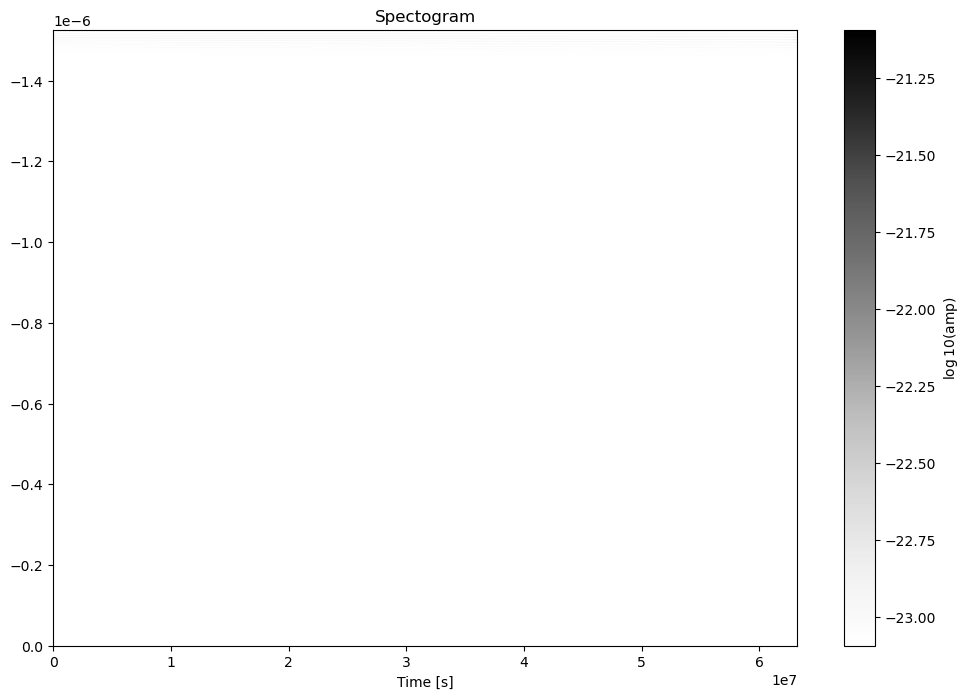

In [30]:
# STFT amplitudes only
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)
cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")
plt.xlabel('Time [s]')
plt.title('Spectogram')
plt.show()

In [31]:
from collections import defaultdict

# sum frequencies for each (l, n)
mode_groups = defaultdict(list)
for i, (ell, m, n) in enumerate(modes):
    mode_groups[(ell, n)].append(mode_freqs[i])
summed_freqs = {}
for (ell, n), freq_list in mode_groups.items():
    summed_freqs[(ell, n)] = np.sum(freq_list, axis=0)


<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1416539/562081210.py:44: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label(f"$\log10$(amp)")
/tmp/ipykernel_1416539/562081210.py:48: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
/tmp/ipykernel_1416539/562081210.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


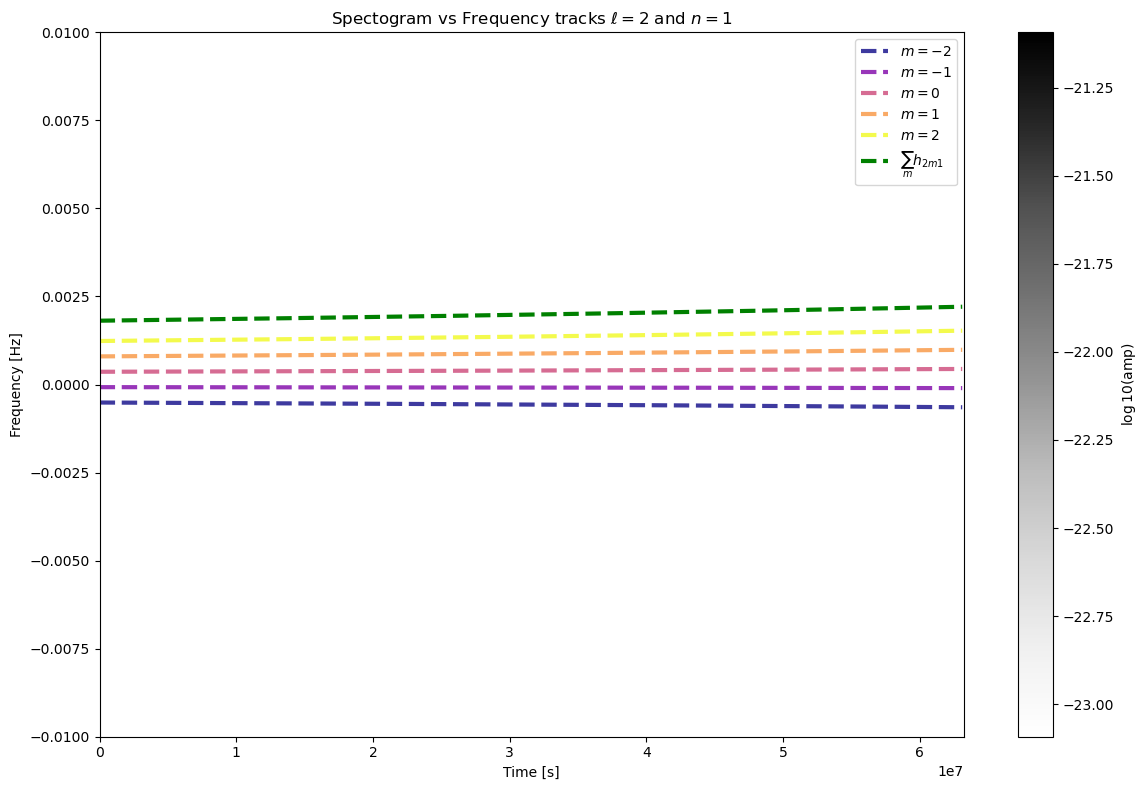

In [32]:
import matplotlib.cm as cm

# Spectogram 
plt.figure(figsize=(12,8))
im = plt.imshow(log_amp, 
               aspect='auto', 
               origin='lower', 
               extent=extent, 
               cmap='Greys',      
               vmin=vmin_val,    
               vmax=max_val)

m_values = np.arange(-2, 3) 
cmap = cm.get_cmap('plasma') 
colors = cmap(np.linspace(0, 1, len(m_values)))

for i, mode in enumerate(modes):
    ell, m, n = mode
    lstyle = 'dashed'
    linewidth = 3
    label = f'$m={m}$'
    if ell == 2 and n == 1:
        color_idx = m + 2  # Map m to color index
        plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=colors[color_idx], linewidth=linewidth, alpha=0.8, label=label)


# # plot each m for (ell=2,n=1)
# for i in range(len(modes)):
#     ell, m, n = modes[i]
#     col = 'red'
#     lstyle = 'dashed'
#     linewidth=3
#     label = f'$m={m}$'
#     if ell==2 and n==1:
#         plt.plot(t_traj_years, mode_freqs[i], linestyle=lstyle, color=col,linewidth=linewidth, alpha=0.8, label=label)
# plot summed freqs for (ell=2, n=1)
# colors = plt.cm.tab10(np.linspace(0, 1, len(summed_freqs)))
for i, ((ell, n), freq) in enumerate(summed_freqs.items()):
    label = r'$\sum_m h_{2m1}$'
    if ell == 2 and n==1:
        plt.plot(t_traj_years, freq, color='green', linewidth=3, linestyle='dashed', alpha=1, label=label)

cbar = plt.colorbar(im)
cbar.set_label(f"$\log10$(amp)")

plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.title('Spectogram vs Frequency tracks $\ell=2$ and $n=1$')
plt.ylim(-0.01,0.01)

plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [33]:
## INCLUDE FOR ALL M 
# just np range 
# 

modes_l2= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-55, 56)
]



modes_l3= [
    (3, m, n) 
    for m in range(-3, 4)
    for n in range(-55, 56)
]

In [34]:
modes_l4= [
    (4, m, n) 
    for m in range(-4, 5)
    for n in range(-55, 56)
]

In [35]:
modes_l2_trunc= [
    (2, m, n) 
    for m in range(-2, 3)
    for n in range(-1, 6)
]

In [36]:
h_l2 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2, include_minus_mkn=False)
h_l3 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l3, include_minus_mkn=False)

(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.
(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


In [37]:
h_l4 = waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l4, include_minus_mkn=False)

(ModeSelector) Warning: Mode selection is large. Instantiate class with mode selection rather than providing it at call time for better performance.


In [38]:
h_l2_trunc =  waveform_gen(*params, T=T, dt=dt, mode_selection = modes_l2_trunc, include_minus_mkn=False)

In [39]:
# nperseg = 2**16  
# noverlap = nperseg * 3 // 4  # 


# f_l2, t_l2, Zxx_l2 = signal.stft(h_l2.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)
# f_l3, t_l3, Zxx_l3 = signal.stft(h_l3.get(), fs=fs, nperseg=nperseg, noverlap=noverlap)



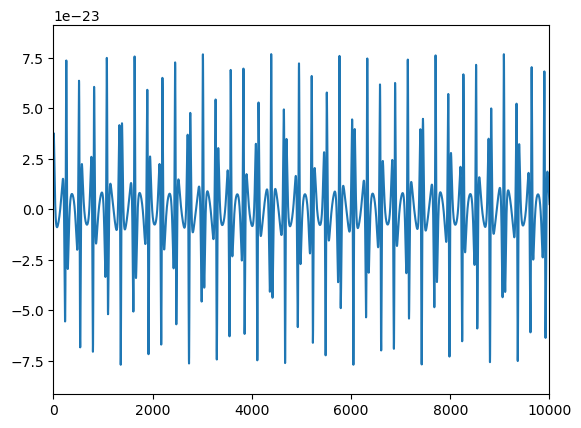

In [40]:
# plt.plot(h_l2.get().real)
plt.plot(h_l3.get().real)
plt.xlim(0,1e4)
plt.show()

In [31]:
# times_before_plunge = [2.0, 3/12, 1/365.25]  # 2y, 3m, 1d
# colors_l2 = ['red', 'green', 'blue']
# colors_l3 = ['orange', 'lightseagreen', 'purple']
# labels_l2 = ['$t_{SNR=30} - 2y$ ($\ell=2$)', '$t_{SNR=30} - 3m$  ($\ell=2$)', '$t_{SNR=30} - 1d$  ($\ell=2$)']
# labels_l3 = ['$t_{SNR=30} - 2y$ ($\ell=3$)', '$t_{SNR=30} - 3m$ ($\ell=3$)', '$t_{SNR=30} - 1d$ ($\ell=3$)']

# fig, ax = plt.subplots()

# for time_bp, color_l2, color_l3, label_l2, label_l3 in zip(times_before_plunge, colors_l2, colors_l3, labels_l2, labels_l3):
#     target_time = -time_bp
#     idx = np.argmin(np.abs(t_years_adjusted - target_time))
#     # amplitude = np.sqrt(Sxx[:, idx])
#     amplitude_l2 = np.abs(Zxx_l2[:, idx])  # or np.sqrt(Sxx[:, idx]) if using spectrogram
#     amplitude_l3 = np.abs(Zxx_l3[:, idx])  

#     ax.plot(f_l2, amplitude_l2, color=color_l2, label=label_l2, linewidth=1.5)
#     ax.plot(f_l3, amplitude_l3, color=color_l3, label=label_l3, linewidth=1.5)


# ax.set_xlabel('Frequency [Hz]')
# ax.set_ylabel('Short-time Fourier amplitude')
# ax.set_xlim([0, 0.004])
# ax.set_ylim([0, None]) 
# ax.legend()

In [41]:
T,dt

(2.0, 10.0)

In [42]:
import GWfuncs

gwf = GWfuncs.GravWaveAnalysis(T, dt)


In [43]:
snr_full = gwf.rhostat(h)
snr_full

array(31.50867907)

In [44]:
snr_l2 = gwf.rhostat(h_l2)
snr_l2 

array(30.31337912)

In [45]:
p_l2 = gwf.rhostat(h_l2)**2/gwf.rhostat(h)**2 *100
p_l2

array(92.55679519)

In [46]:
snr_l2_trunc = gwf.rhostat(h_l2_trunc)
snr_l2_trunc

array(27.05096679)

In [47]:
p_l2_trunc = gwf.rhostat(h_l2_trunc)**2/gwf.rhostat(h)**2 *100
p_l2_trunc

array(73.70639819)

In [37]:
snr_l3 = gwf.rhostat(h_l3)
snr_l3

array(1.38974219)

In [38]:
p_l3 = gwf.rhostat(h_l3)**2/gwf.rhostat(h)**2 *100
p_l3

array(0.19453963)

In [42]:
p_l4 = gwf.rhostat(h_l4)**2/gwf.rhostat(h)**2 *100
p_l4

array(0.00068518)

In [39]:
np.sqrt(snr_l2**2+snr_l3**2)/snr_full*100

array(96.30749442)

In [106]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [107]:
# so i can make sure of the order we'll do it manually
h_neg1 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[0],  
    include_minus_mkn=False,
)

h_0 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[1],  
    include_minus_mkn=False,
)


h_1 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[2],  
    include_minus_mkn=False,
)

h_2 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[3],  
    include_minus_mkn=False,
)

h_3 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[4],  
    include_minus_mkn=False,
)

h_4 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[5],  
    include_minus_mkn=False,
)

h_5 = waveform_gen(*params,
    dt=dt,
    T=T,
    mode_selection=groups[6],  
    include_minus_mkn=False,
)

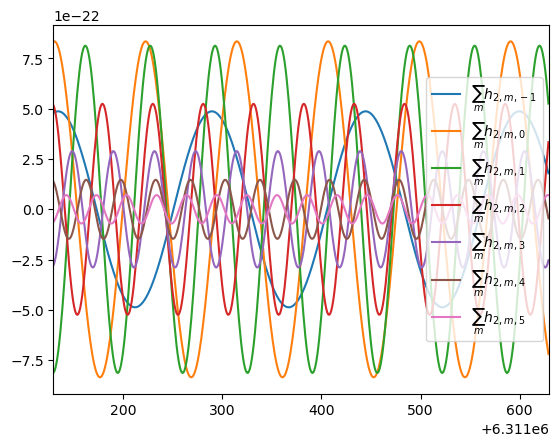

In [108]:
plt.plot(h_neg1.get().real, label=r'$\sum_m h_{2,m,-1}$')
plt.plot(h_0.get().real, label=r'$\sum_m h_{2,m,0}$')
plt.plot(h_1.get().real, label=r'$\sum_m h_{2,m,1}$')
plt.plot(h_2.get().real, label=r'$\sum_m h_{2,m,2}$')
plt.plot(h_3.get().real, label=r'$\sum_m h_{2,m,3}$')
plt.plot(h_4.get().real, label=r'$\sum_m h_{2,m,4}$')
plt.plot(h_5.get().real, label=r'$\sum_m h_{2,m,5}$')
plt.xlim(len(h_0)-500, len(h_0))
plt.legend(loc='right')
plt.show()

In [109]:
waveforms = [h_neg1, h_0, h_1, h_2, h_3, h_4, h_5]                                                                                                                                               

# compute as matrixx
n = len(waveforms)
overlap_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        hi_f = gwf.freq_wave(waveforms[i])
        hj_f = gwf.freq_wave(waveforms[j])
        overlap_matrix[i,j] = gwf.overlap(hi_f, hj_f)





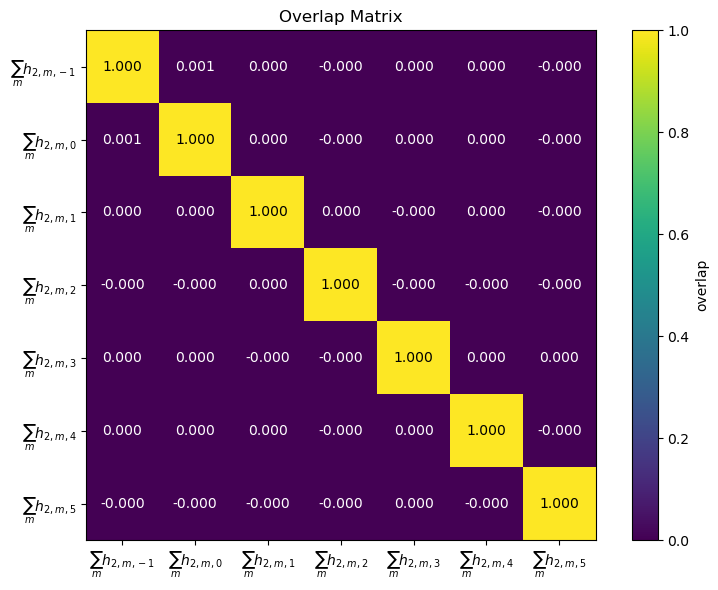

In [110]:
# Display as heatmap
labels = [                                                                                                                                                                                       
    r'$\sum_m h_{2,m,-1}$',                                                      
    r'$\sum_m h_{2,m,0}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,1}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,2}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,3}$',                                                                                                                                                                         
    r'$\sum_m h_{2,m,4}$',                                                                                                                                                                       
    r'$\sum_m h_{2,m,5}$',
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(overlap_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.colorbar(im, label='overlap')
ax.set_title('Overlap Matrix')

# Annotate cells with values
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{overlap_matrix[i, j]:.3f}',
                ha='center', va='center', color='white' if overlap_matrix[i, j] < 0.5 else 'black')

plt.tight_layout()
plt.show()
